In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../results/shap', exist_ok=True)

# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

feature_names = X_test.columns.tolist()

feature_family_map = {
    'Protocol': 'Protocol/Other',

    'Flow Duration': 'Timing',
    'Flow IAT Mean': 'Timing',
    'Flow IAT Max': 'Timing',
    'Flow IAT Min': 'Timing',
    'Fwd IAT Total': 'Timing',
    'Fwd IAT Mean': 'Timing',
    'Fwd IAT Max': 'Timing',
    'Fwd IAT Min': 'Timing',
    'Active Mean': 'Timing',
    'Active Std': 'Timing',
    'Active Max': 'Timing',
    'Idle Mean': 'Timing',
    'Idle Max': 'Timing',
    'Idle Min': 'Timing',

    'Fwd Packet Length Max': 'Packet Size',
    'Fwd Packet Length Min': 'Packet Size',
    'Fwd Packet Length Mean': 'Packet Size',
    'Bwd Packet Length Min': 'Packet Size',
    'Bwd Packet Length Mean': 'Packet Size',
    'Packet Length Min': 'Packet Size',
    'Packet Length Max': 'Packet Size',
    'Packet Length Mean': 'Packet Size',
    'Packet Length Std': 'Packet Size',
    'Packet Length Variance': 'Packet Size',
    'Average Packet Size': 'Packet Size',
    'Fwd Segment Size Avg': 'Packet Size',
    'Bwd Segment Size Avg': 'Packet Size',

    'SYN Flag Count': 'TCP Flags',
    'RST Flag Count': 'TCP Flags',
}

LABEL_MAP = {0: 'Benign', 1: 'DDoS', 2: 'DoS', 3: 'Mirai', 4: 'Spoofing'}

# 1000 rows for fast models
X_shap_sample = X_test.sample(1000, random_state=42)
y_shap_sample = y_test.loc[X_shap_sample.index]

# 200 rows for slow models (RF, BRF)
X_shap_small = X_test.sample(200, random_state=42)
y_shap_small = y_test.loc[X_shap_small.index]

# Attack-only subsets
X_shap_attacks       = X_shap_sample[y_shap_sample != 0]
X_shap_attacks_small = X_shap_small[y_shap_small != 0]

print(f"Fast sample: {X_shap_sample.shape}")
print(f"Slow sample: {X_shap_small.shape}")
print(f"Attack sample (fast): {X_shap_attacks.shape}")
print(f"Attack sample (slow): {X_shap_attacks_small.shape}")
print(f"Models available: {os.listdir('../results/models/')}")

Fast sample: (1000, 30)
Slow sample: (200, 30)
Attack sample (fast): (698, 30)
Attack sample (slow): (138, 30)
Models available: ['hier_stage1_DT.pkl', 'hier_stage1_ET.pkl', 'hier_stage2_HGB.pkl', 'hier_stage1_LGBM.pkl', 'hier_stage2_RF.pkl', 'hier_stage1_HGB.pkl', 'hier_stage2_LGBM.pkl', 'hier_stage2_ET.pkl', 'hier_stage1_BRF.pkl', 'hier_stage2_XGB.pkl', 'hier_stage1_CAT.pkl', 'hier_stage2_DT.pkl', 'hier_stage2_BRF.pkl', 'hier_stage1_RF.pkl', 'hier_stage1_XGB.pkl', 'hier_stage2_CAT.pkl']


In [2]:
def get_shap_importance(model, X_sample):
    """Returns (1D importance, 2D shap matrix) handling all output formats."""
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)

    if isinstance(shap_values, np.ndarray):
        if shap_values.ndim == 3:
            sv_2d = shap_values[:, :, 0]
        else:
            sv_2d = shap_values
    elif isinstance(shap_values, list):
        sv_2d = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    else:
        sv_2d = np.array(shap_values)

    importance = np.abs(sv_2d).mean(axis=0)
    return importance, sv_2d


def plot_shap_bar(sv_2d, X_sample, title, save_path):
    """Plot and save global SHAP bar chart using 2D matrix."""
    shap.summary_plot(
        sv_2d,
        X_sample,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


print("Helper functions ready")

Helper functions ready



Stage 1 SHAP — DT (1000 rows)...


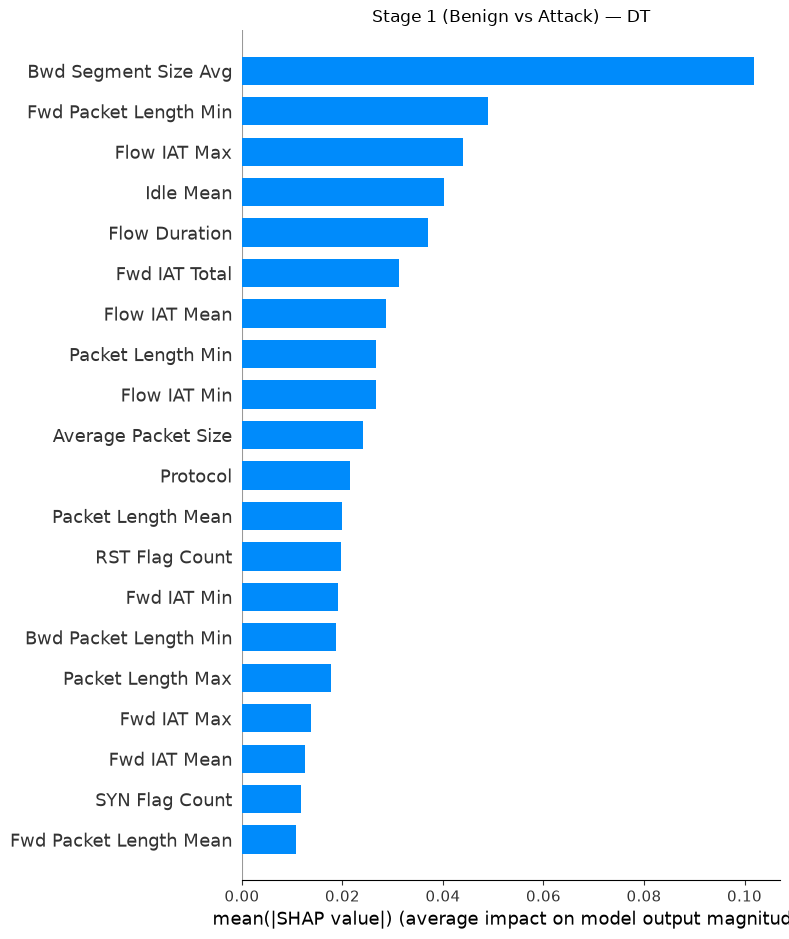

Saved: stage1_DT_global.png

Stage 1 SHAP — XGB (1000 rows)...


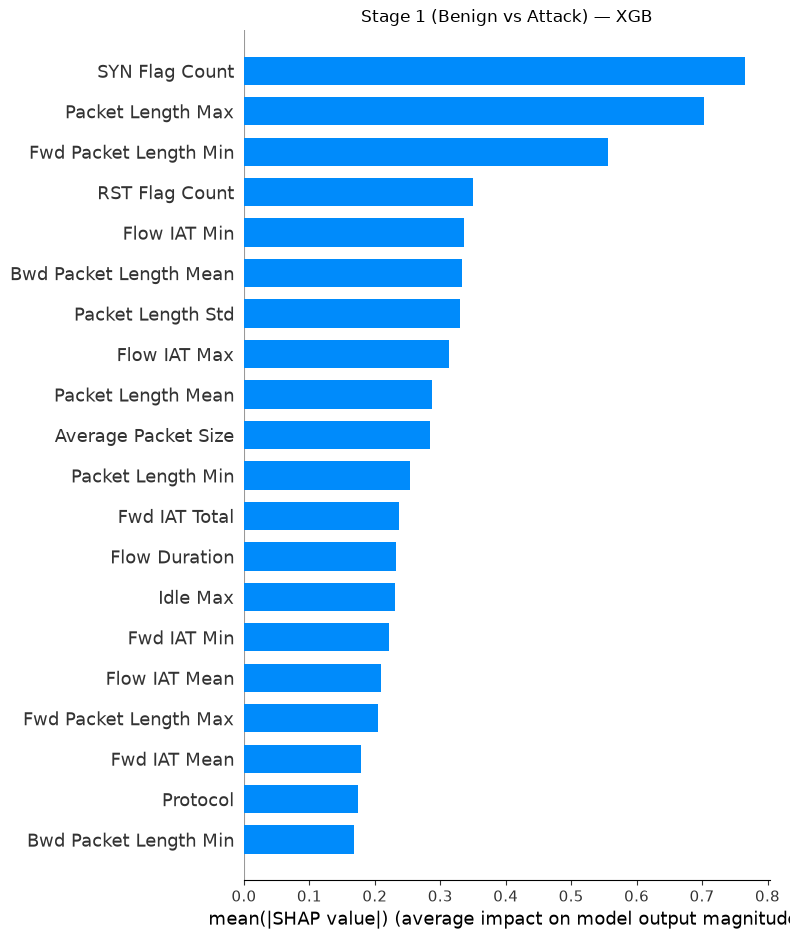

Saved: stage1_XGB_global.png

Stage 1 SHAP — LGBM (1000 rows)...


/Users/simrahruq/Documents/GitHub/flat-vs-hierarchical-ml-research/iot-research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


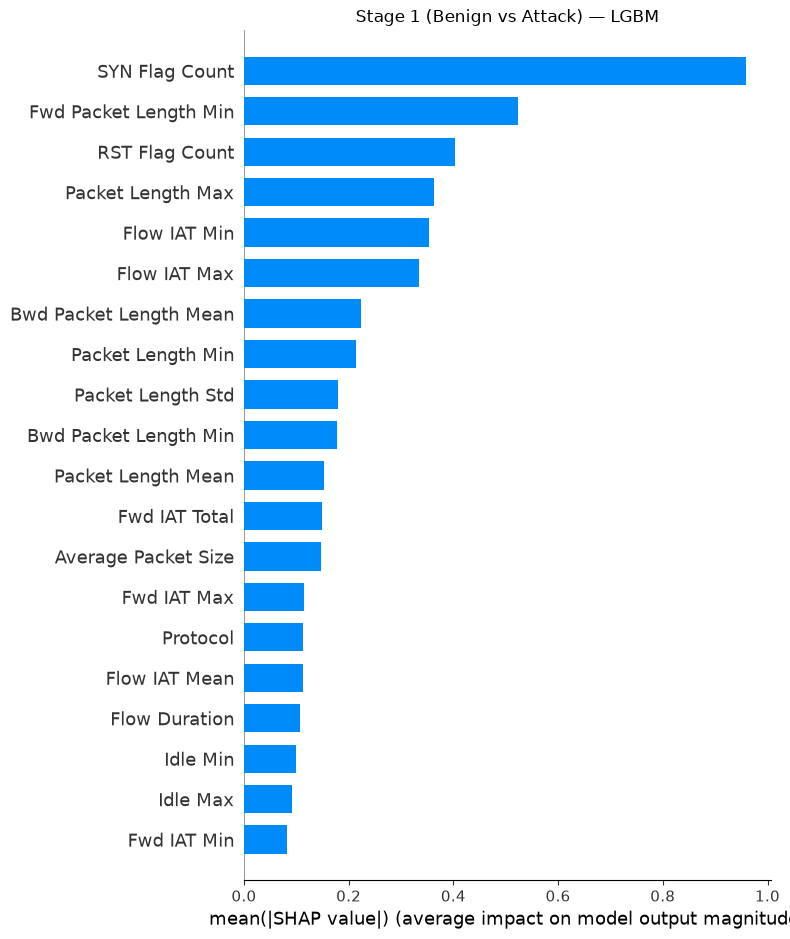

Saved: stage1_LGBM_global.png

Stage 1 SHAP — CAT (1000 rows)...


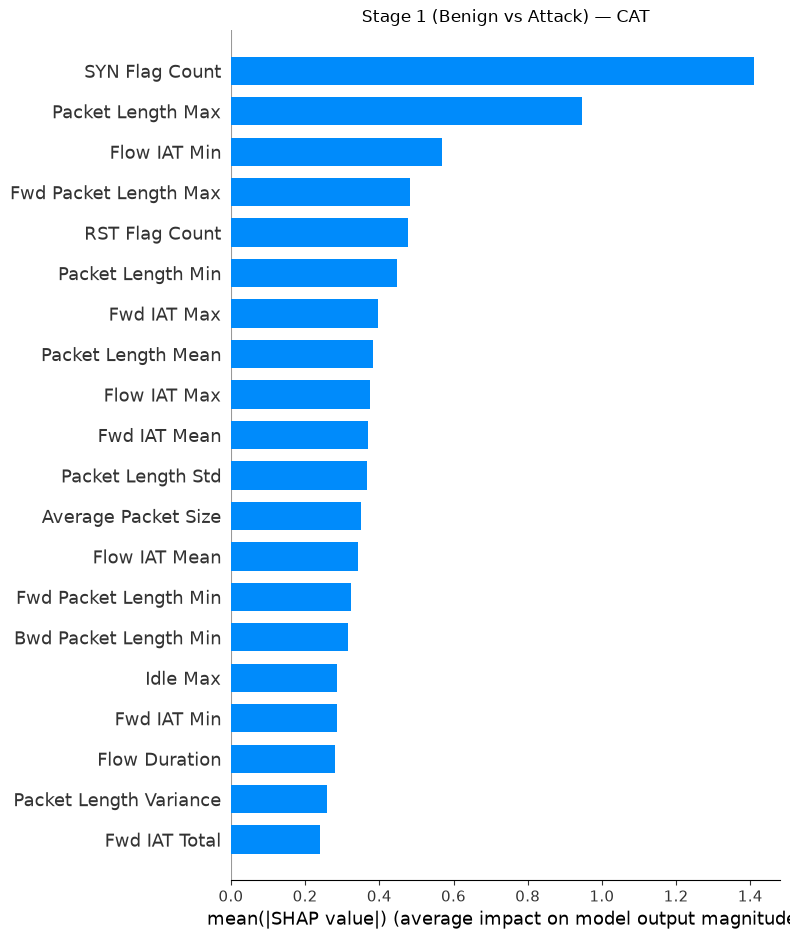

Saved: stage1_CAT_global.png

Stage 1 SHAP — RF (200 rows)...


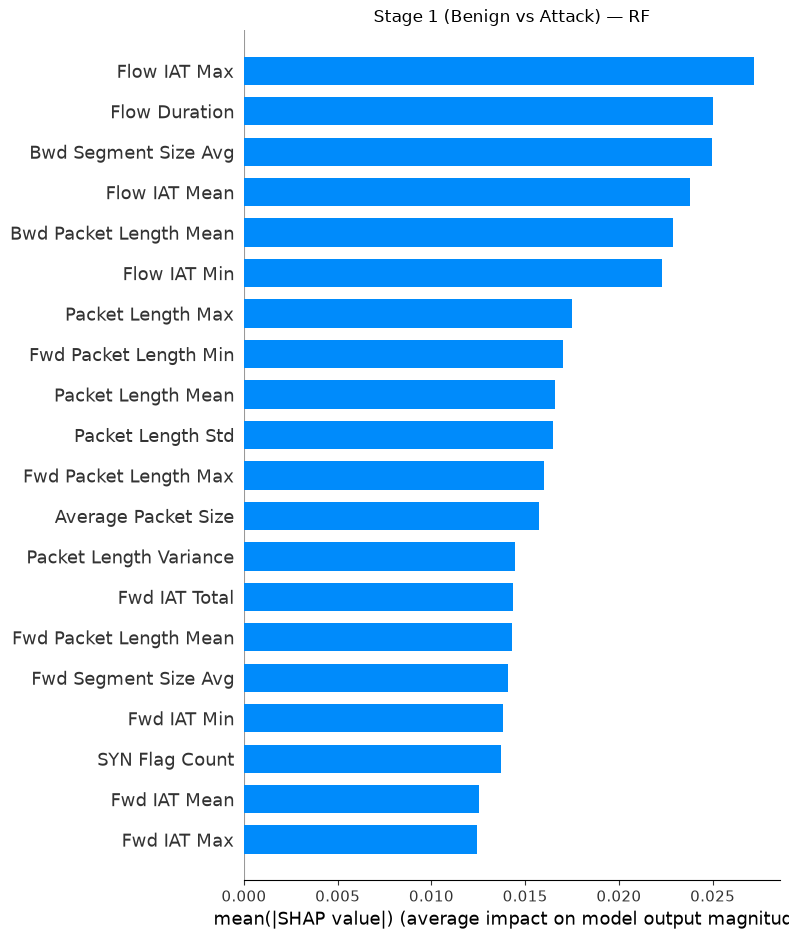

Saved: stage1_RF_global.png

Stage 1 SHAP — BRF (200 rows)...


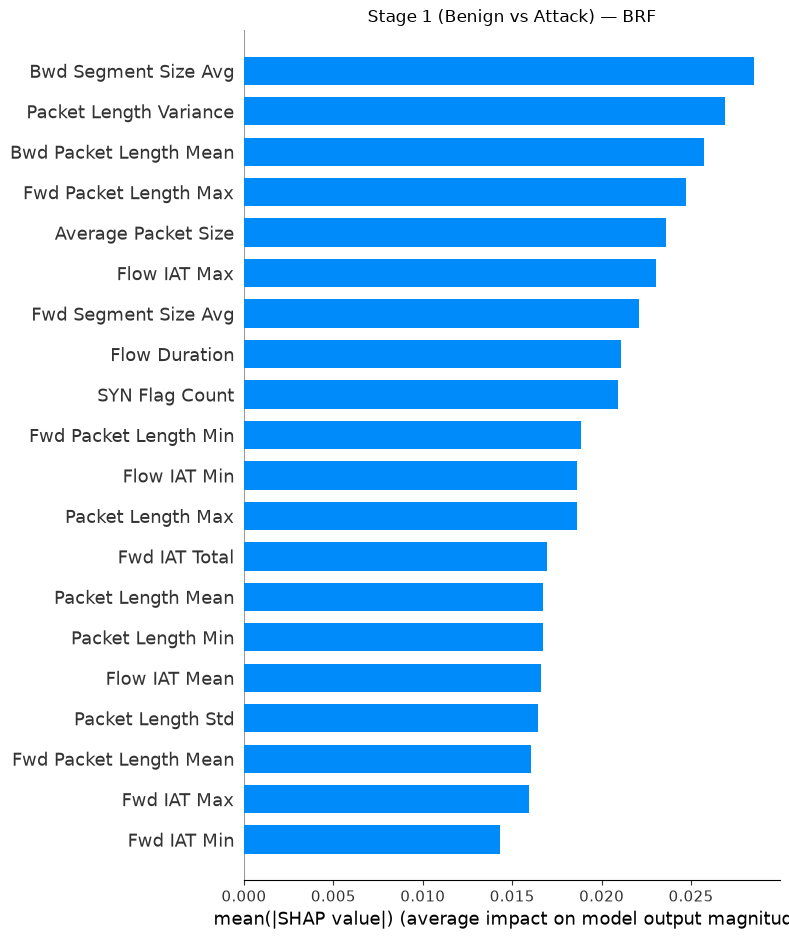

Saved: stage1_BRF_global.png

All Stage 1 SHAP done


In [3]:
fast_models = ['DT', 'XGB', 'LGBM', 'CAT']
slow_models = ['RF', 'BRF']

stage1_importance = {}
stage1_sv         = {}

# Fast models — 1000 rows
for model_name in fast_models:
    print(f"\nStage 1 SHAP — {model_name} (1000 rows)...")
    model = joblib.load(f'../results/models/hier_stage1_{model_name}.pkl')
    importance, sv_2d = get_shap_importance(model, X_shap_sample)
    stage1_importance[model_name] = importance
    stage1_sv[model_name] = sv_2d

    plot_shap_bar(
        sv_2d,
        X_shap_sample,
        f"Stage 1 (Benign vs Attack) — {model_name}",
        f"../results/shap/stage1_{model_name}_global.png"
    )
    print(f"Saved: stage1_{model_name}_global.png")

# Slow models — 200 rows
for model_name in slow_models:
    print(f"\nStage 1 SHAP — {model_name} (200 rows)...")
    model = joblib.load(f'../results/models/hier_stage1_{model_name}.pkl')
    importance, sv_2d = get_shap_importance(model, X_shap_small)
    stage1_importance[model_name] = importance
    stage1_sv[model_name] = sv_2d

    plot_shap_bar(
        sv_2d,
        X_shap_small,
        f"Stage 1 (Benign vs Attack) — {model_name}",
        f"../results/shap/stage1_{model_name}_global.png"
    )
    print(f"Saved: stage1_{model_name}_global.png")

print("\nAll Stage 1 SHAP done")


Stage 2 SHAP — DT (attack rows)...


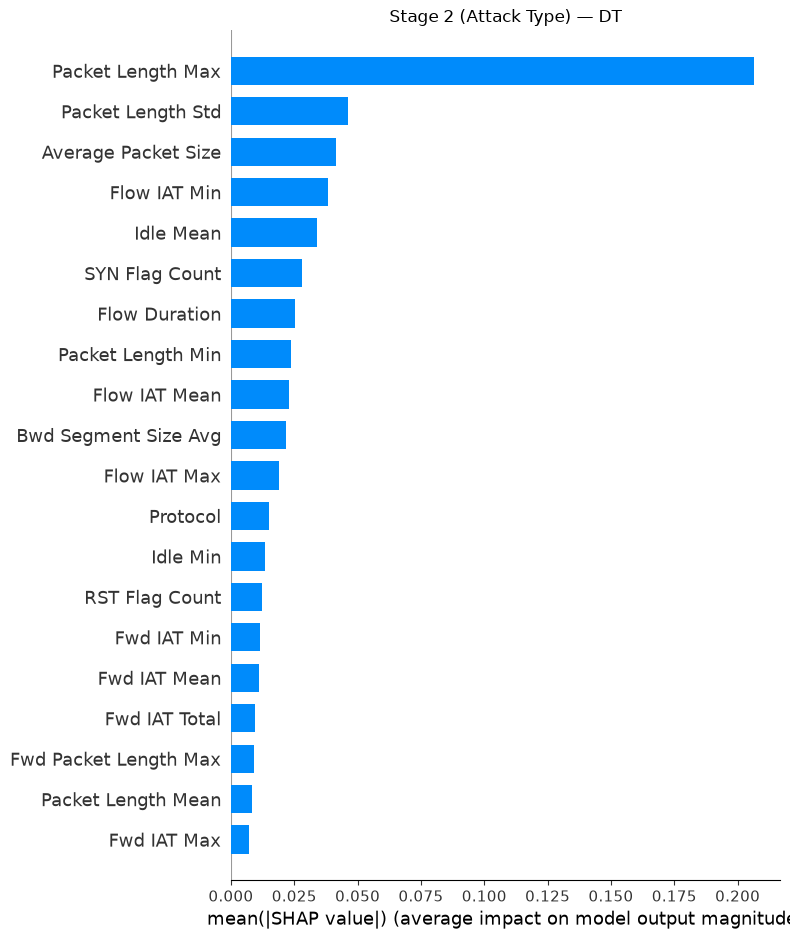

Saved: stage2_DT_global.png

Stage 2 SHAP — XGB (attack rows)...


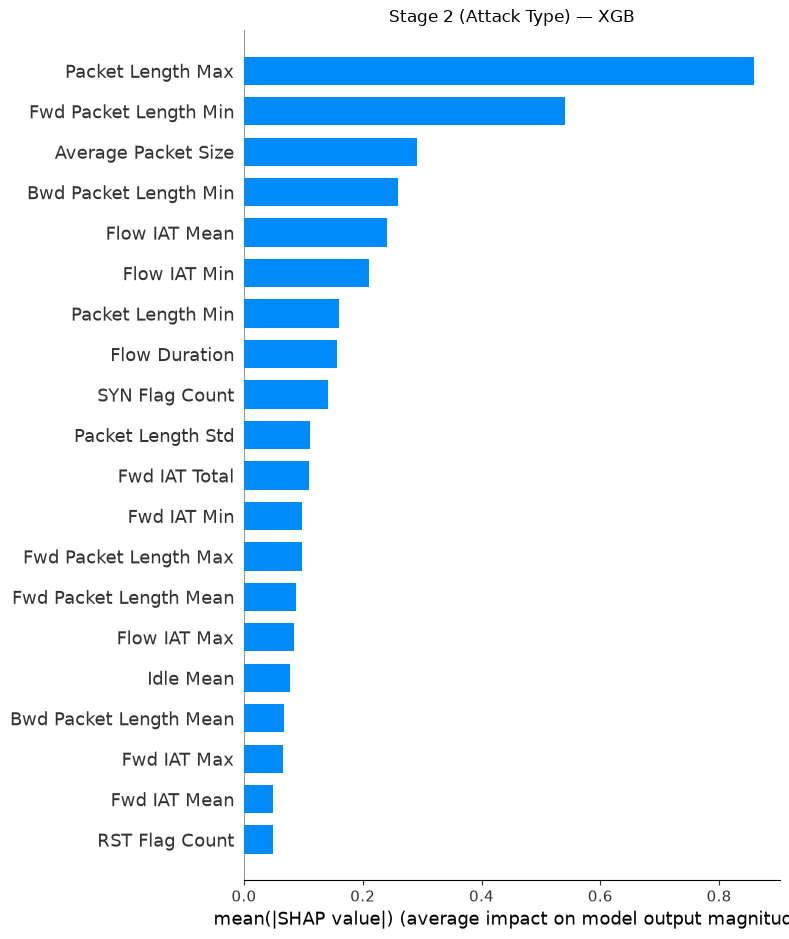

Saved: stage2_XGB_global.png

Stage 2 SHAP — LGBM (attack rows)...


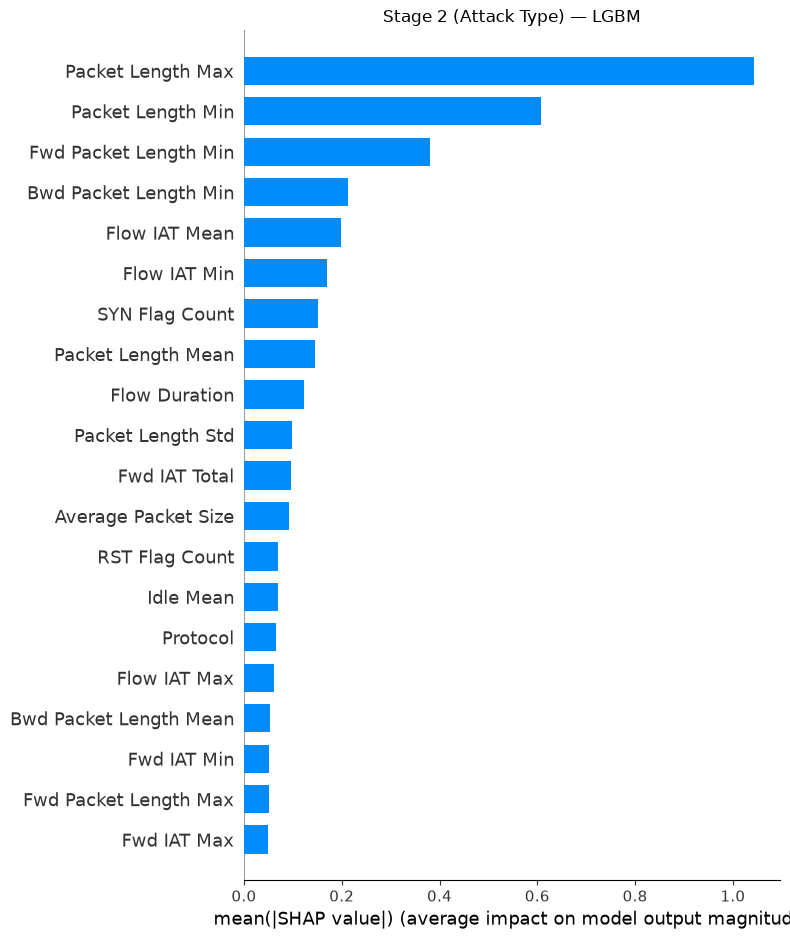

Saved: stage2_LGBM_global.png

Stage 2 SHAP — CAT (attack rows)...


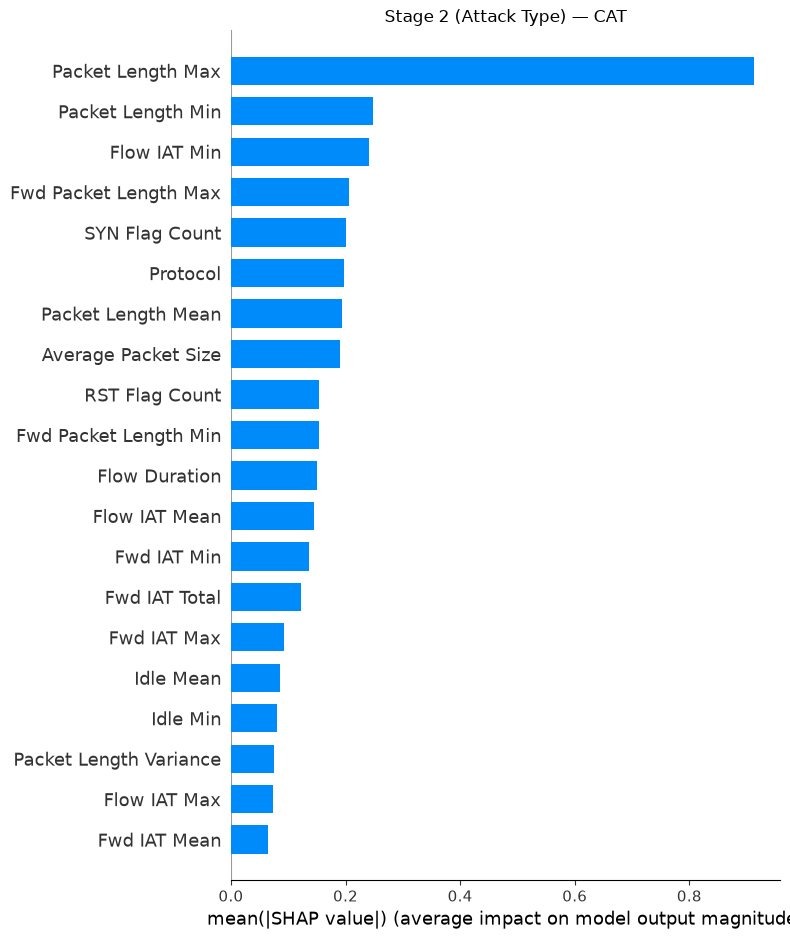

Saved: stage2_CAT_global.png

Stage 2 SHAP — RF (200 rows)...


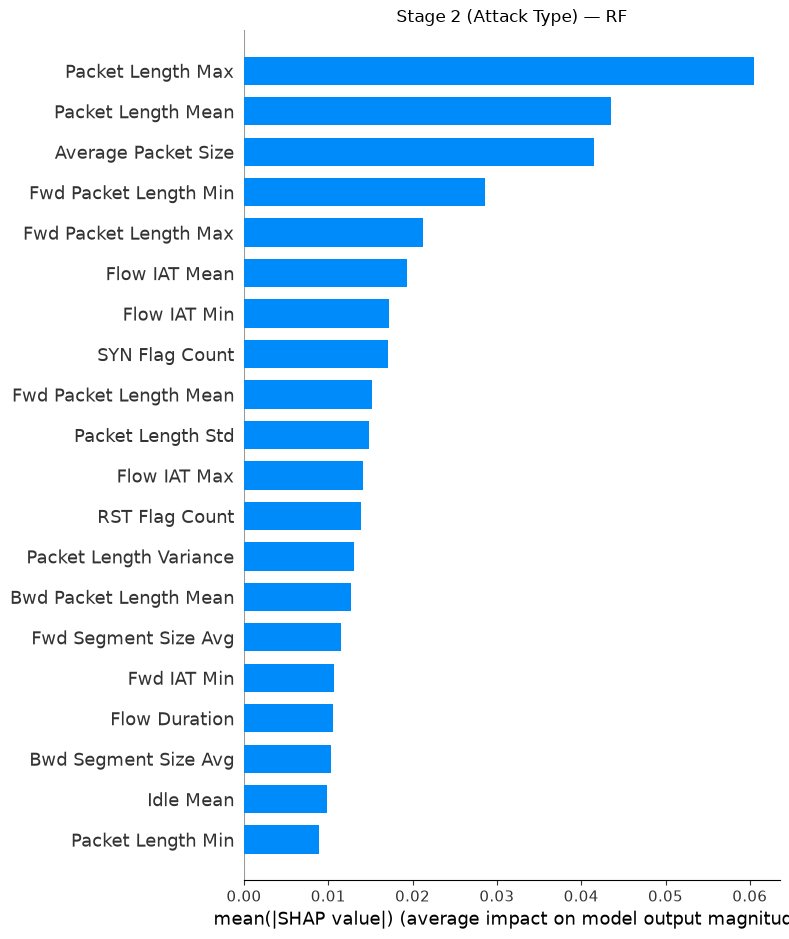

Saved: stage2_RF_global.png

Stage 2 SHAP — BRF (200 rows)...


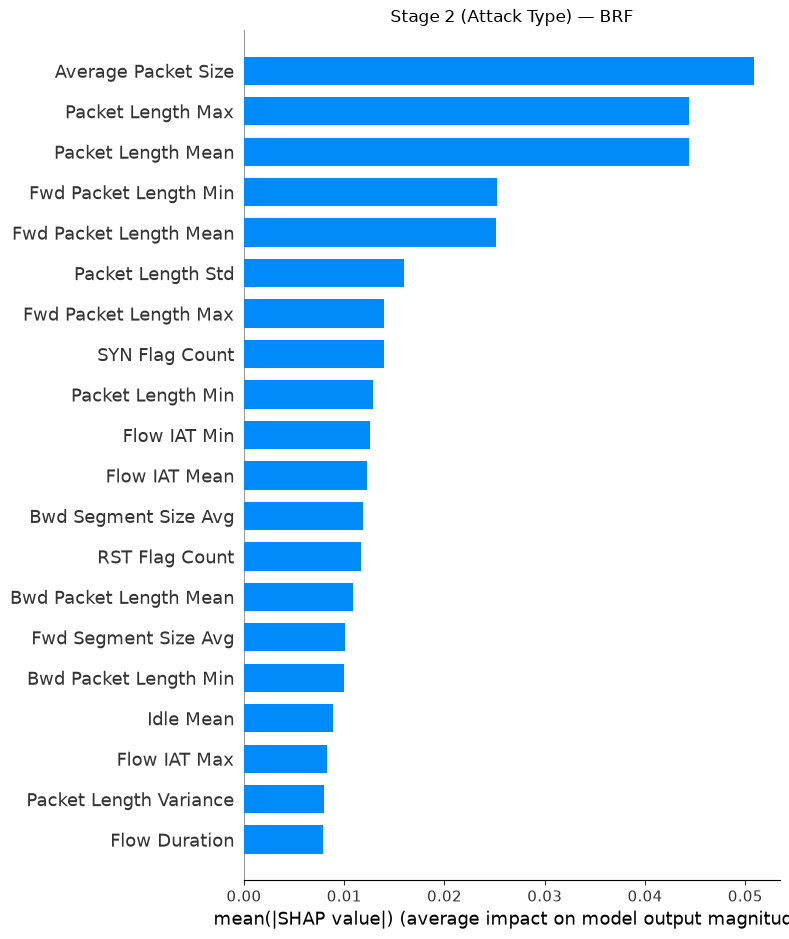

Saved: stage2_BRF_global.png

All Stage 2 SHAP done


In [4]:
stage2_importance = {}
stage2_sv         = {}

# Fast models
for model_name in fast_models:
    print(f"\nStage 2 SHAP — {model_name} (attack rows)...")
    model = joblib.load(f'../results/models/hier_stage2_{model_name}.pkl')
    importance, sv_2d = get_shap_importance(model, X_shap_attacks)
    stage2_importance[model_name] = importance
    stage2_sv[model_name] = sv_2d

    plot_shap_bar(
        sv_2d,
        X_shap_attacks,
        f"Stage 2 (Attack Type) — {model_name}",
        f"../results/shap/stage2_{model_name}_global.png"
    )
    print(f"Saved: stage2_{model_name}_global.png")

# Slow models
for model_name in slow_models:
    print(f"\nStage 2 SHAP — {model_name} (200 rows)...")
    model = joblib.load(f'../results/models/hier_stage2_{model_name}.pkl')
    importance, sv_2d = get_shap_importance(model, X_shap_attacks_small)
    stage2_importance[model_name] = importance
    stage2_sv[model_name] = sv_2d

    plot_shap_bar(
        sv_2d,
        X_shap_attacks_small,
        f"Stage 2 (Attack Type) — {model_name}",
        f"../results/shap/stage2_{model_name}_global.png"
    )
    print(f"Saved: stage2_{model_name}_global.png")

print("\nAll Stage 2 SHAP done")


Comparison plot — DT...


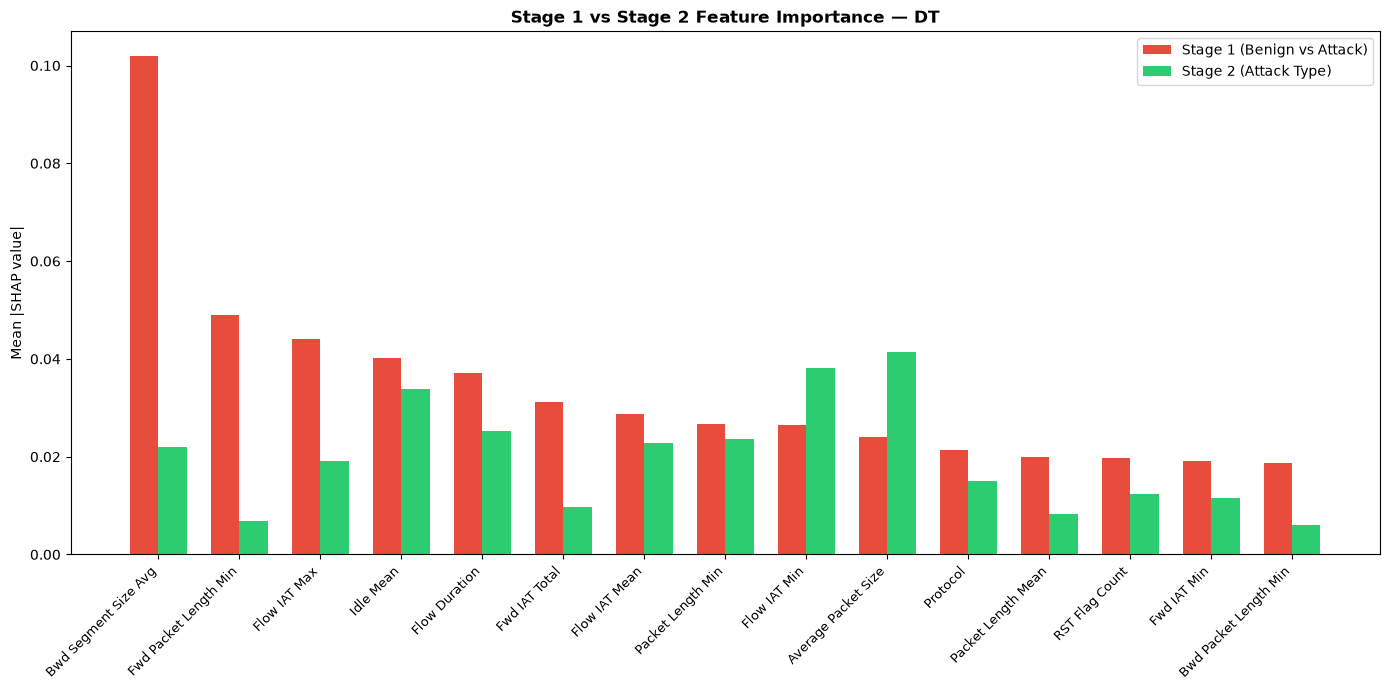

Saved: comparison_DT.png

Comparison plot — XGB...


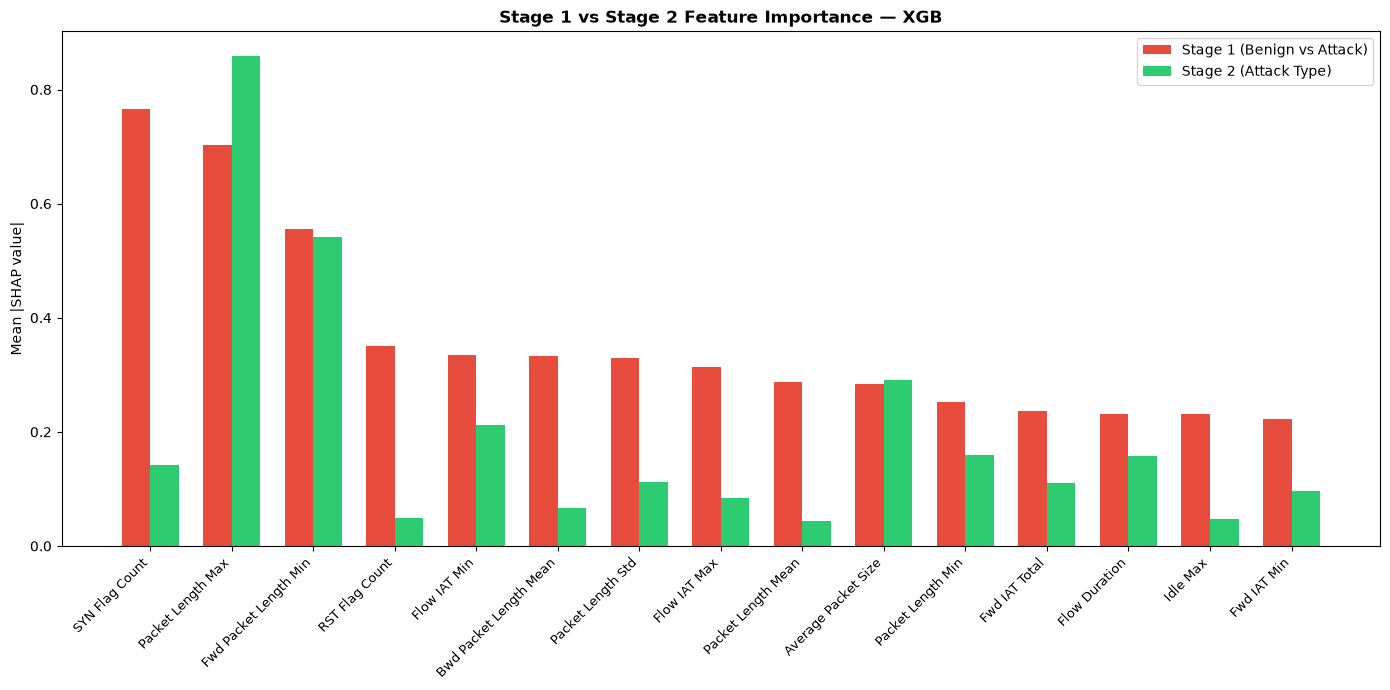

Saved: comparison_XGB.png

Comparison plot — LGBM...


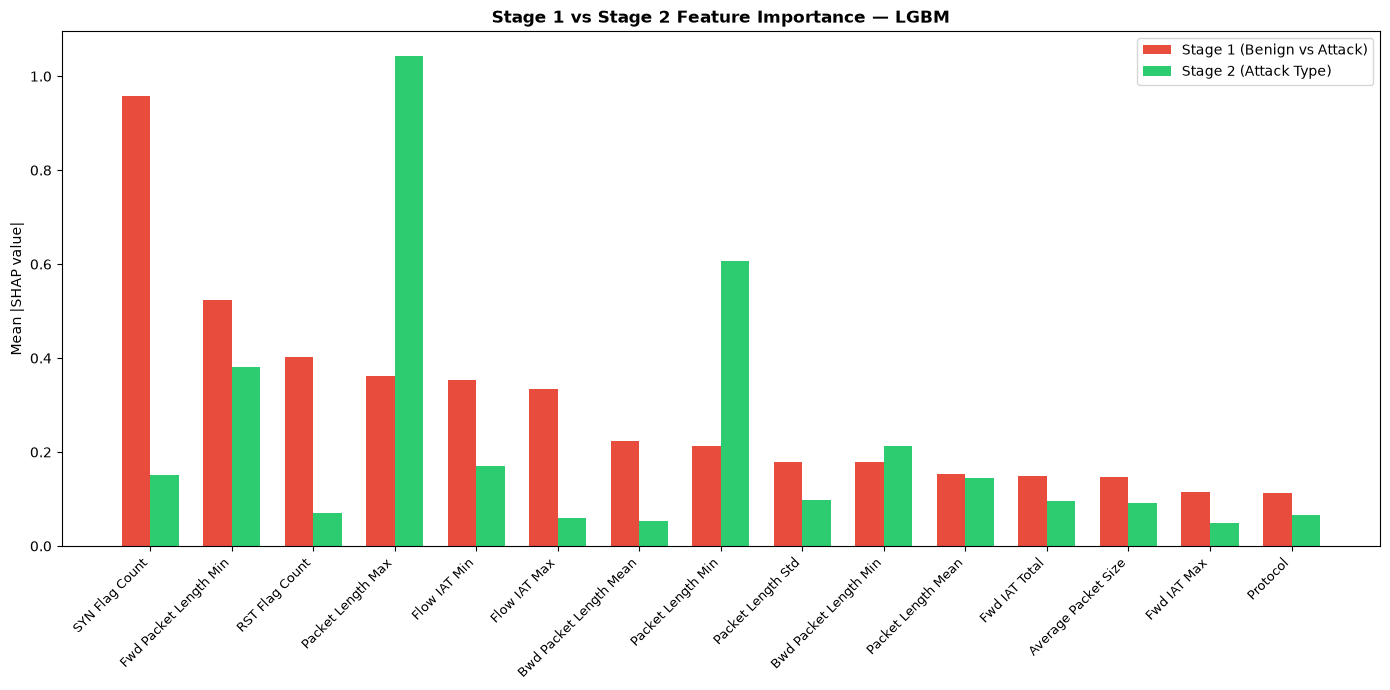

Saved: comparison_LGBM.png

Comparison plot — CAT...


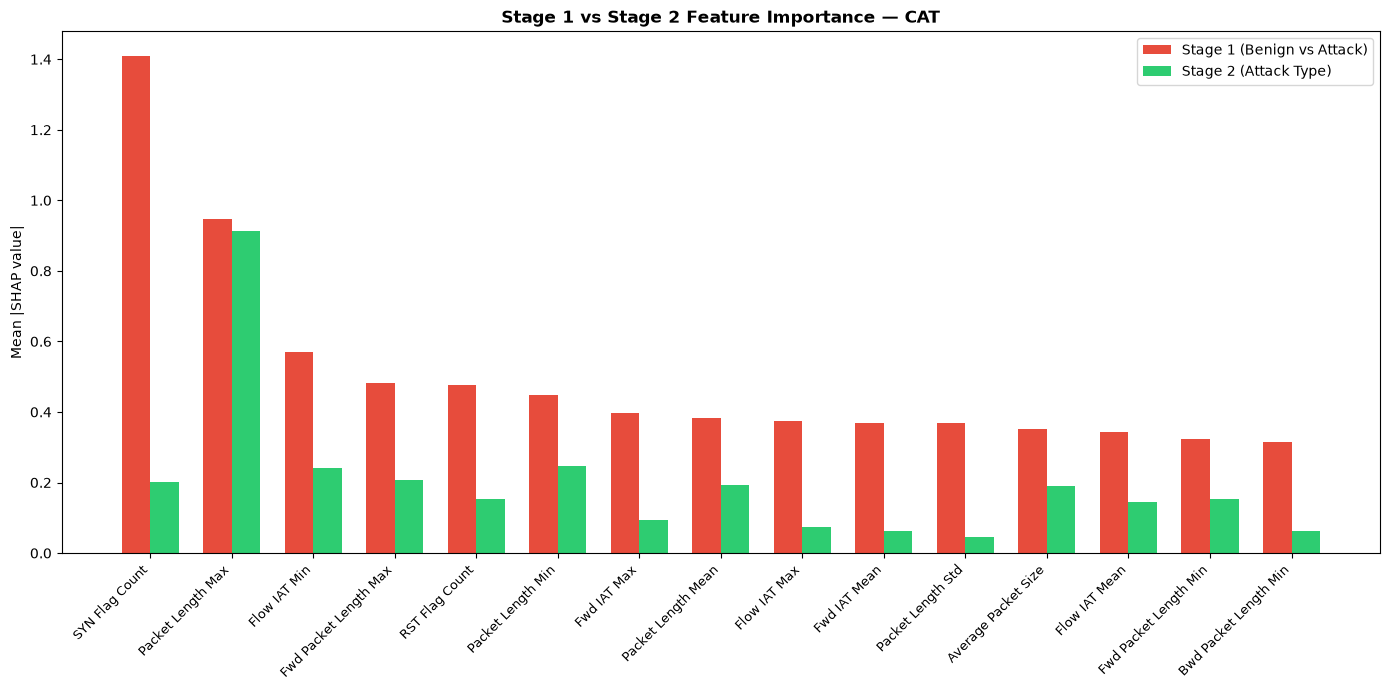

Saved: comparison_CAT.png

Comparison plot — RF...


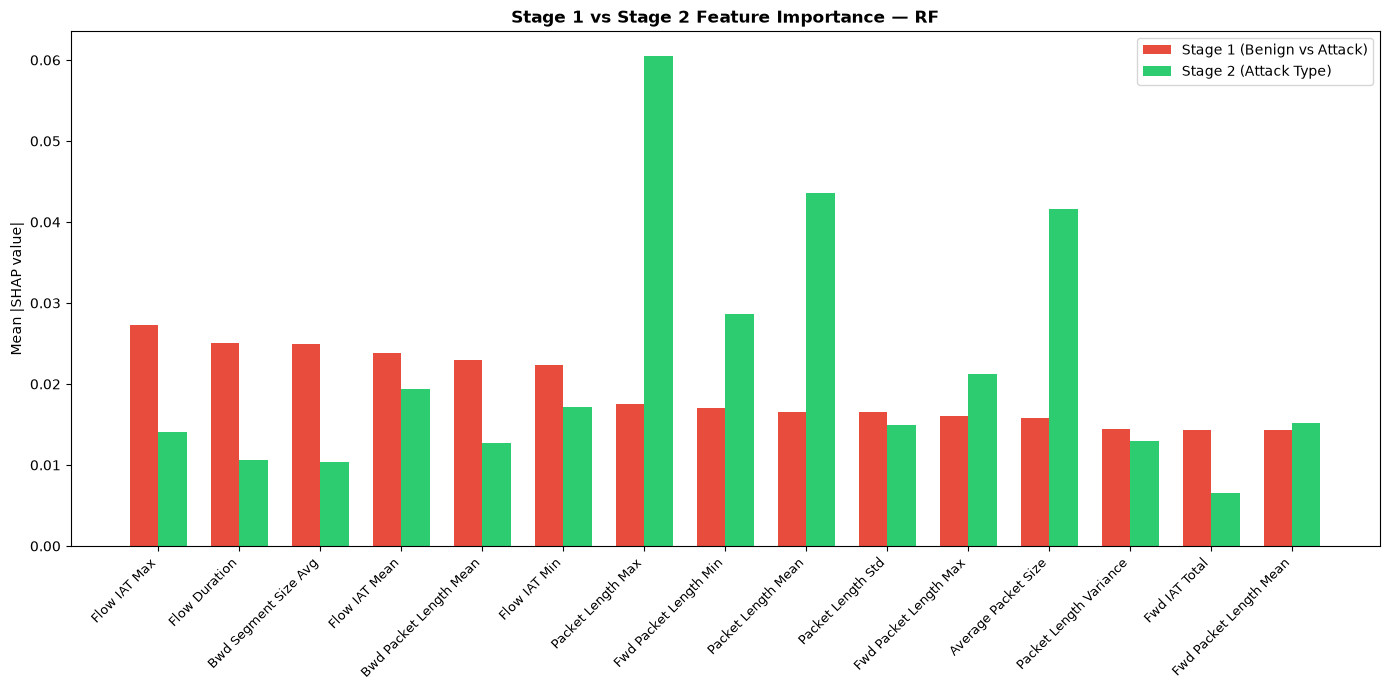

Saved: comparison_RF.png

Comparison plot — BRF...


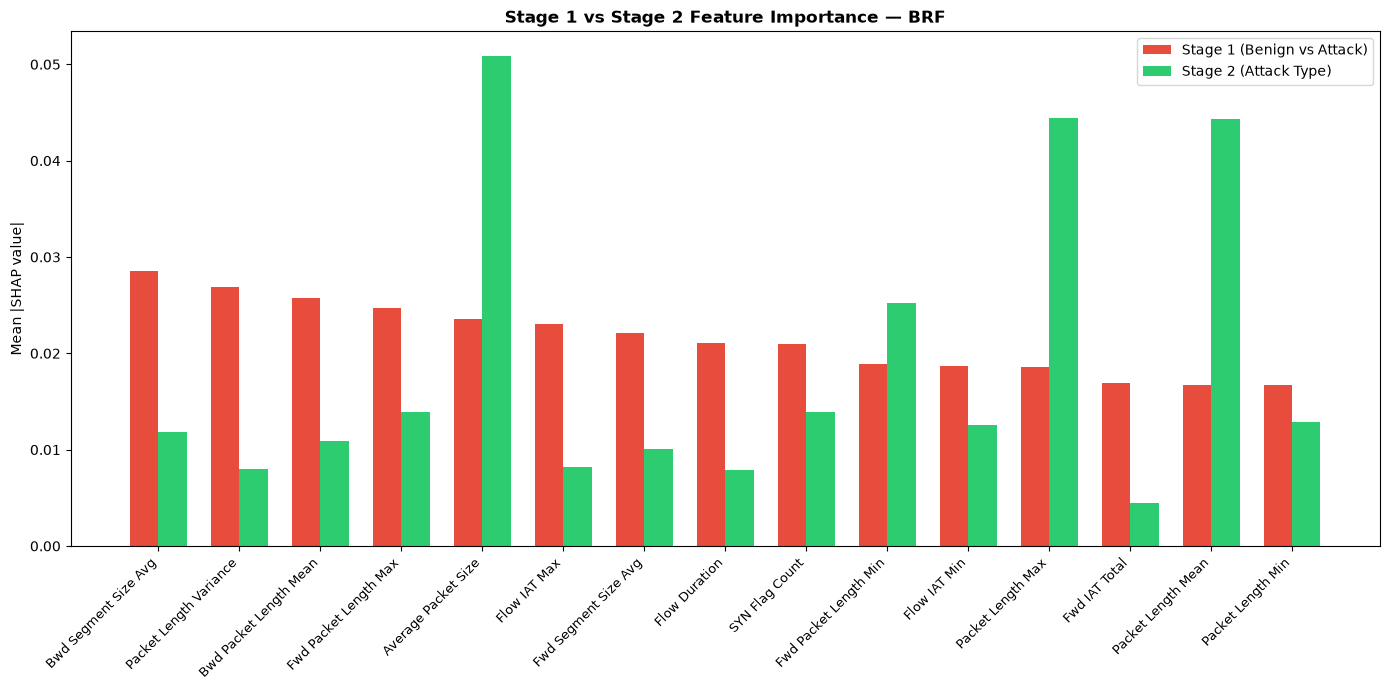

Saved: comparison_BRF.png

All comparison plots done


In [5]:
all_models = fast_models + slow_models

for model_name in all_models:
    print(f"\nComparison plot — {model_name}...")

    comparison_df = pd.DataFrame({
        'Feature': feature_names,
        'Stage 1 (Binary)': stage1_importance[model_name],
        'Stage 2 (Attack Type)': stage2_importance[model_name],
    }).sort_values('Stage 1 (Binary)', ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(14, 7))
    x = np.arange(len(comparison_df))
    w = 0.35

    ax.bar(x - w/2, comparison_df['Stage 1 (Binary)'],
           w, label='Stage 1 (Benign vs Attack)', color='#e74c3c')
    ax.bar(x + w/2, comparison_df['Stage 2 (Attack Type)'],
           w, label='Stage 2 (Attack Type)', color='#2ecc71')

    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df['Feature'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Mean |SHAP value|')
    ax.set_title(f'Stage 1 vs Stage 2 Feature Importance — {model_name}',
                 fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'../results/shap/comparison_{model_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: comparison_{model_name}.png")

print("\nAll comparison plots done")

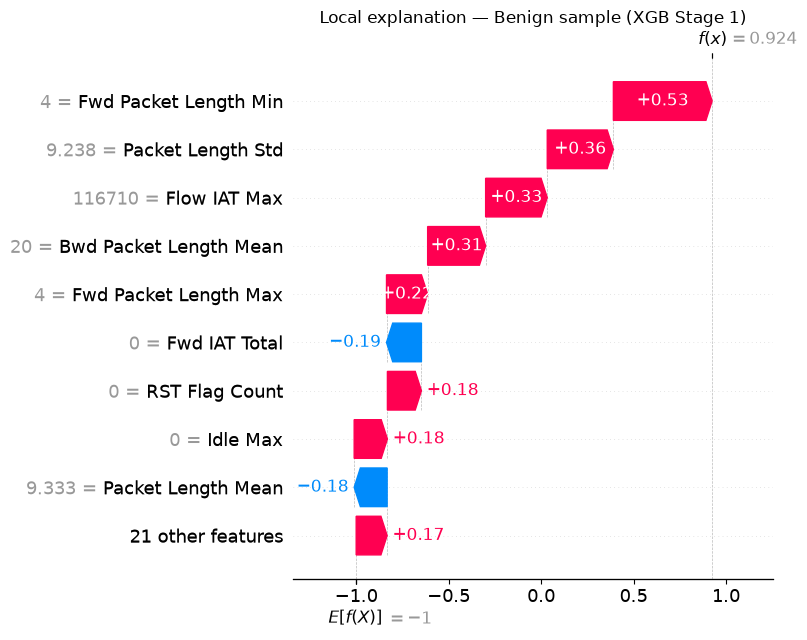

Saved: local_Benign.png


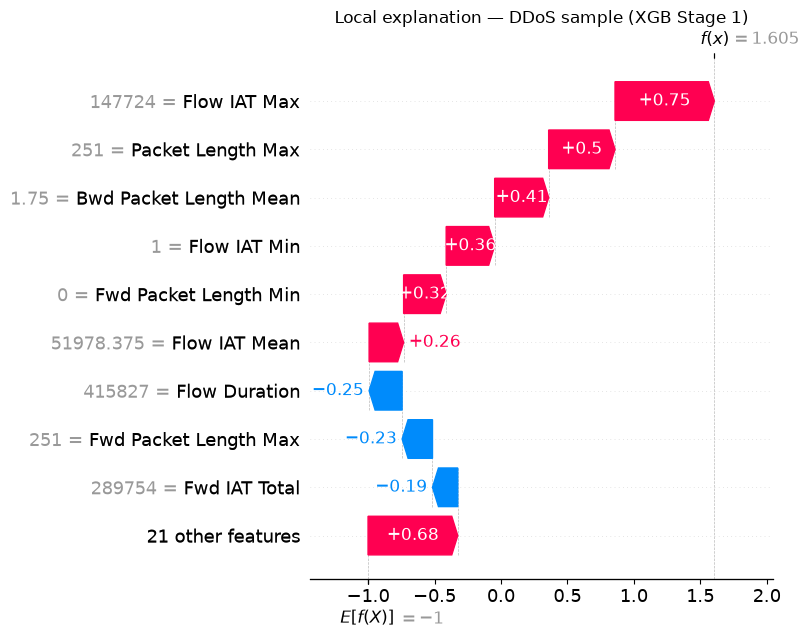

Saved: local_DDoS.png


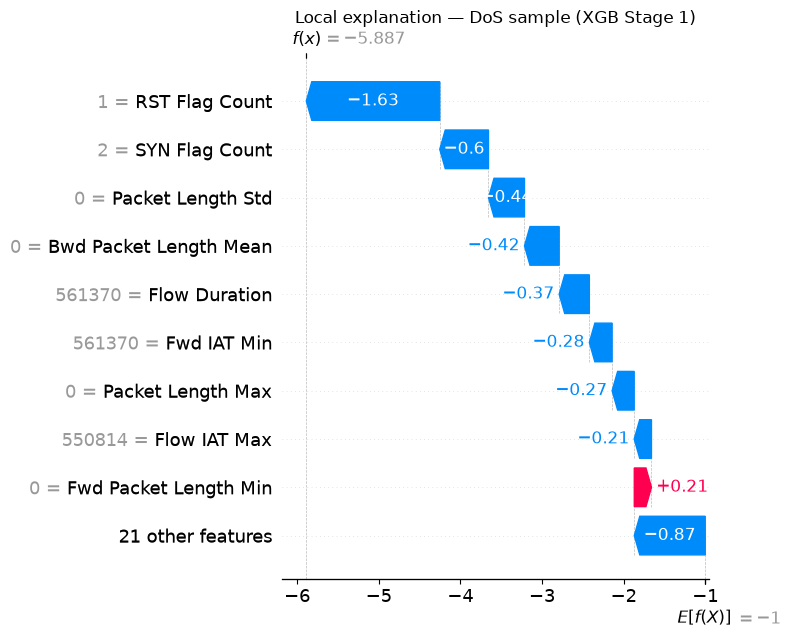

Saved: local_DoS.png


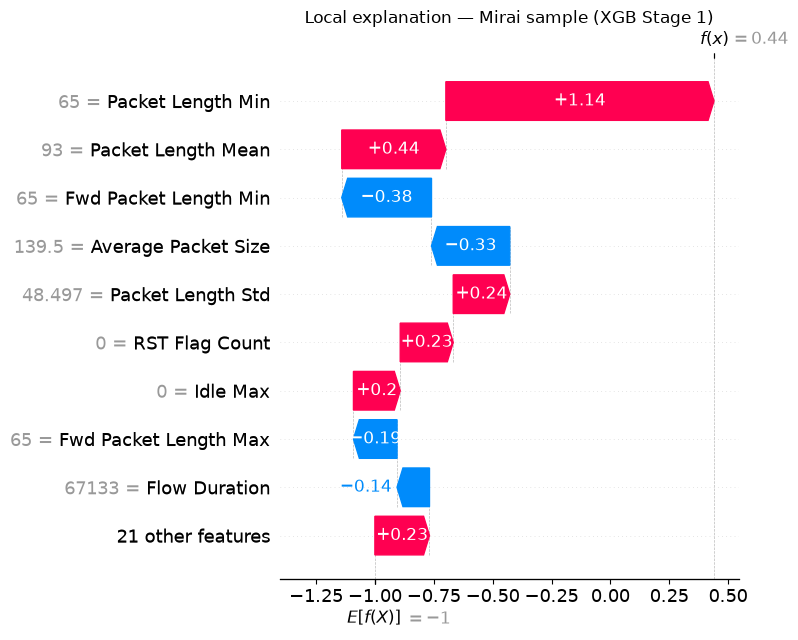

Saved: local_Mirai.png


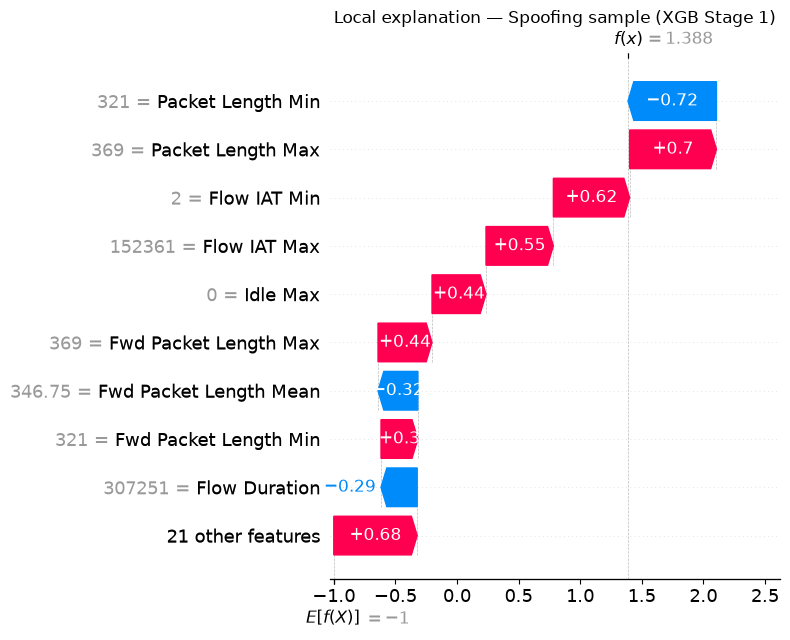

Saved: local_Spoofing.png

All local explanations done


In [6]:
model = joblib.load('../results/models/hier_stage1_XGB.pkl')
explainer = shap.TreeExplainer(model)

for class_label, class_name in LABEL_MAP.items():
    idx    = y_test[y_test == class_label].index[0]
    sample = X_test.loc[[idx]]

    sv = explainer.shap_values(sample)

    if isinstance(sv, np.ndarray) and sv.ndim == 3:
        sv_plot = sv[0, :, 0]
        ev = explainer.expected_value[0] if hasattr(
            explainer.expected_value, '__len__') else explainer.expected_value
    elif isinstance(sv, list):
        sv_plot = sv[0][0]
        ev = explainer.expected_value[0]
    else:
        sv_plot = sv[0]
        ev = explainer.expected_value

    shap.waterfall_plot(
        shap.Explanation(
            values=sv_plot,
            base_values=ev,
            data=sample.values[0],
            feature_names=feature_names
        ),
        show=False
    )
    plt.title(f"Local explanation — {class_name} sample (XGB Stage 1)")
    plt.tight_layout()
    plt.savefig(f'../results/shap/local_{class_name}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"Saved: local_{class_name}.png")

print("\nAll local explanations done")

In [7]:
# Print exact top 15 SHAP values for each model at each stage
print("=== STAGE 1 IMPORTANCE (exact) ===")
for model_name in fast_models + slow_models:
    if model_name in stage1_importance:
        imp = stage1_importance[model_name]
        top_idx = np.argsort(imp)[::-1][:15]
        print(f"\n{model_name}:")
        for i in top_idx:
            print(f"  {feature_names[i]}: {imp[i]:.4f}")

print("\n=== STAGE 2 IMPORTANCE (exact) ===")
for model_name in fast_models + slow_models:
    if model_name in stage2_importance:
        imp = stage2_importance[model_name]
        top_idx = np.argsort(imp)[::-1][:15]
        print(f"\n{model_name}:")
        for i in top_idx:
            print(f"  {feature_names[i]}: {imp[i]:.4f}")

=== STAGE 1 IMPORTANCE (exact) ===

DT:
  Bwd Segment Size Avg: 0.1020
  Fwd Packet Length Min: 0.0490
  Flow IAT Max: 0.0440
  Idle Mean: 0.0401
  Flow Duration: 0.0371
  Fwd IAT Total: 0.0312
  Flow IAT Mean: 0.0287
  Packet Length Min: 0.0267
  Flow IAT Min: 0.0266
  Average Packet Size: 0.0240
  Protocol: 0.0214
  Packet Length Mean: 0.0200
  RST Flag Count: 0.0197
  Fwd IAT Min: 0.0192
  Bwd Packet Length Min: 0.0187

XGB:
  SYN Flag Count: 0.7653
  Packet Length Max: 0.7034
  Fwd Packet Length Min: 0.5555
  RST Flag Count: 0.3501
  Flow IAT Min: 0.3356
  Bwd Packet Length Mean: 0.3336
  Packet Length Std: 0.3302
  Flow IAT Max: 0.3132
  Packet Length Mean: 0.2874
  Average Packet Size: 0.2840
  Packet Length Min: 0.2531
  Fwd IAT Total: 0.2366
  Flow Duration: 0.2319
  Idle Max: 0.2305
  Fwd IAT Min: 0.2221

LGBM:
  SYN Flag Count: 0.9590
  Fwd Packet Length Min: 0.5241
  RST Flag Count: 0.4027
  Packet Length Max: 0.3621
  Flow IAT Min: 0.3543
  Flow IAT Max: 0.3350
  Bwd Packet

In [8]:
import numpy as np
import pandas as pd

def normalize_and_aggregate(importance_array, feature_names, family_map):
    """Normalize importances to sum to 1, then aggregate by feature family."""
    norm_imp = importance_array / importance_array.sum()
    df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': norm_imp,
        'Family': [family_map.get(f, 'Protocol/Other') for f in feature_names]
    })
    family_imp = df.groupby('Family')['Importance'].sum().sort_values(ascending=False)
    return family_imp, df

# Stage 1 RF
stage1_rf_family, stage1_rf_detail = normalize_and_aggregate(
    stage1_importance['RF'], feature_names, feature_family_map
)
print("Stage 1 (RF) — family-level importance:")
print(stage1_rf_family)

# Stage 2 BRF
stage2_brf_family, stage2_brf_detail = normalize_and_aggregate(
    stage2_importance['BRF'], feature_names, feature_family_map
)
print("\nStage 2 (BRF) — family-level importance:")
print(stage2_brf_family)

Stage 1 (RF) — family-level importance:
Family
Packet Size       0.493284
Timing            0.434067
TCP Flags         0.052582
Protocol/Other    0.020066
Name: Importance, dtype: float64

Stage 2 (BRF) — family-level importance:
Family
Packet Size       0.700356
Timing            0.219150
TCP Flags         0.063192
Protocol/Other    0.017303
Name: Importance, dtype: float64


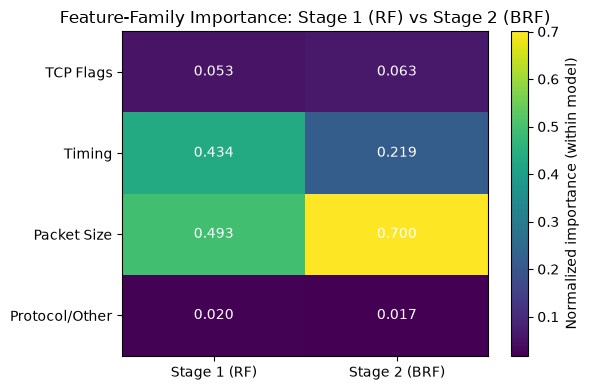

In [10]:
import matplotlib.pyplot as plt

all_families = ['TCP Flags', 'Timing', 'Packet Size', 'Protocol/Other']

heatmap_data = pd.DataFrame({
    'Stage 1 (RF)': [stage1_rf_family.get(f, 0) for f in all_families],
    'Stage 2 (BRF)': [stage2_brf_family.get(f, 0) for f in all_families],
}, index=all_families)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(heatmap_data.values.astype(float), aspect='auto', cmap='viridis')
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha='center', va='center', color='white')
fig.colorbar(im, ax=ax, label='Normalized importance (within model)')
plt.title('Feature-Family Importance: Stage 1 (RF) vs Stage 2 (BRF)')
plt.tight_layout()
plt.savefig('../results/shap/family_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
from scipy.stats import spearmanr

stage1_norm = stage1_importance['RF'] / stage1_importance['RF'].sum()
stage2_norm = stage2_importance['BRF'] / stage2_importance['BRF'].sum()

rho, p_value = spearmanr(stage1_norm, stage2_norm)
print(f"Spearman correlation (Stage 1 RF vs Stage 2 BRF): rho={rho:.3f}, p={p_value:.4f}")

k = 10
top_k_s1 = set(np.argsort(stage1_norm)[::-1][:k])
top_k_s2 = set(np.argsort(stage2_norm)[::-1][:k])
overlap = top_k_s1 & top_k_s2
print(f"Top-{k} feature overlap: {len(overlap)}/{k} features")
print(f"Shared top-{k} features: {[feature_names[i] for i in overlap]}")

Spearman correlation (Stage 1 RF vs Stage 2 BRF): rho=0.564, p=0.0012
Top-10 feature overlap: 5/10 features
Shared top-10 features: ['Fwd Packet Length Min', 'Flow IAT Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std']
